# 6CS012 Final Assessment – Part III: Language Tasks

## Sentiment Analysis using RNN, LSTM, and GloVe + LSTM

## 4.5.1 Text Preprocessing, Tokenization, and Sequence Padding

### Step 1: Import Required Libraries

In [53]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import time
import warnings

warnings.filterwarnings("ignore")

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Deep learning libraries
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)

Libraries imported successfully.
TensorFlow version: 2.20.0


### Step 2: Dataset Loading and Initial Understanding

In [54]:
df = pd.read_csv("/content/Hotel_Reviews.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (20491, 2)


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [55]:
print("Columns in dataset:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nRating classes:")
print(sorted(df['Rating'].unique()))

print("\nDataset information:")
df.info()

Columns in dataset:
Index(['Review', 'Rating'], dtype='object')

Missing values:
Review    0
Rating    0
dtype: int64

Duplicate rows: 0

Rating classes:
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


### Step 3: Dataset Understanding and Class Distribution

Class Distribution:

Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


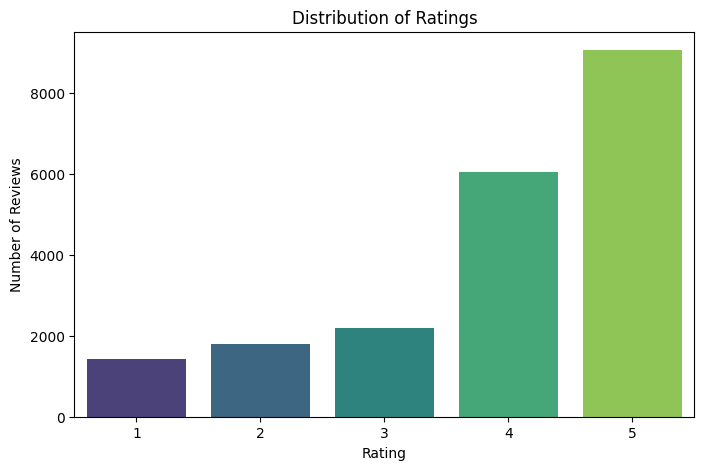

In [56]:
# Count ratings
rating_counts = df["Rating"].value_counts().sort_index()

print("Class Distribution:\n")
print(rating_counts)

# Plot class distribution
plt.figure(figsize=(8,5))

sns.countplot(
    x=df["Rating"],
    palette="viridis"
)

plt.title("Distribution of Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")

plt.show()

### Step 4: Selecting Required Columns and Cleaning Missing Values

In [57]:
# Select required columns
df = df[["Review", "Rating"]]

# Rename columns
df.columns = ["review", "rating"]

# Remove missing values
df.dropna(inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Final dataset shape:", df.shape)

display(df.head())

Final dataset shape: (20491, 2)


,review,rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


### Step 6: Text Cleaning

This step converts raw review text into a clean format by applying lowercase conversion, contraction handling, URL removal, mention removal, hashtag removal, number removal, special character removal, stopword removal, and lemmatization.

In [58]:
# Basic contraction dictionary
contractions_dict = {
    "don't": "do not",
    "doesn't": "does not",
    "didn't": "did not",
    "can't": "cannot",
    "couldn't": "could not",
    "won't": "will not",
    "wouldn't": "would not",
    "shouldn't": "should not",
    "isn't": "is not",
    "aren't": "are not",
    "wasn't": "was not",
    "weren't": "were not",
    "haven't": "have not",
    "hasn't": "has not",
    "hadn't": "had not",
    "i'm": "i am",
    "i've": "i have",
    "i'll": "i will",
    "you're": "you are",
    "you've": "you have",
    "it's": "it is",
    "that's": "that is",
    "there's": "there is",
    "what's": "what is"
}

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for contraction, expanded in contractions_dict.items():
        text = text.replace(contraction, expanded)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)



In [59]:
df["clean_review"] = df["review"].apply(clean_text)

display(df[["review", "clean_review", "rating"]].head())

,review,clean_review,rating
0,nice hotel expensive parking got good deal sta...,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,nice room experience hotel monaco seattle good...,3
3,"unique, great stay, wonderful time hotel monac...",unique great stay wonderful time hotel monaco ...,5
4,"great stay great stay, went seahawk game aweso...",great stay great stay went seahawk game awesom...,5


### Step 7: Most Frequent Words Visualization

          Word  Frequency
0        hotel      52956
1         room      46378
2        great      21098
3           nt      19007
4         good      17054
5        staff      16280
6         stay      15341
7        night      14085
8          day      12961
9         time      12611
10        nice      12412
11    location      11236
12     service      10538
13      stayed      10469
14  restaurant      10092
15       beach      10047
16   breakfast       9655
17       place       9381
18       clean       9373
19        food       9259


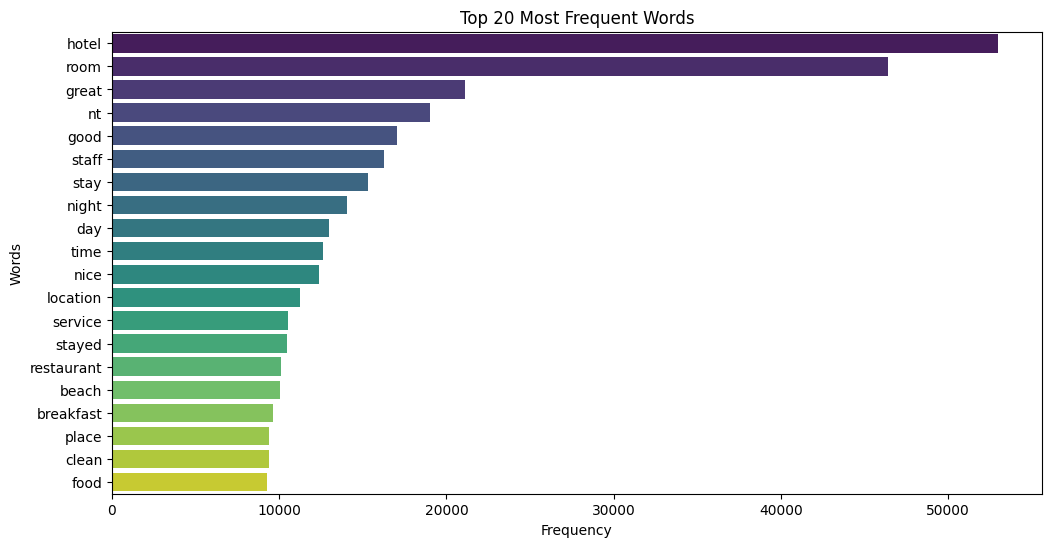

In [61]:
from collections import Counter

# Combine all cleaned reviews
all_words = " ".join(df["clean_review"]).split()

# Count word frequencies
word_freq = Counter(all_words)

# Get top 20 words
top_words = word_freq.most_common(20)

# Convert to dataframe
top_words_df = pd.DataFrame(top_words, columns=["Word", "Frequency"])

print(top_words_df)

# Plot top words
plt.figure(figsize=(12,6))

sns.barplot(
    x="Frequency",
    y="Word",
    data=top_words_df,
    palette="viridis"
)

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

In [63]:
!pip install wordcloud


### Step 8: Word Cloud Visualization

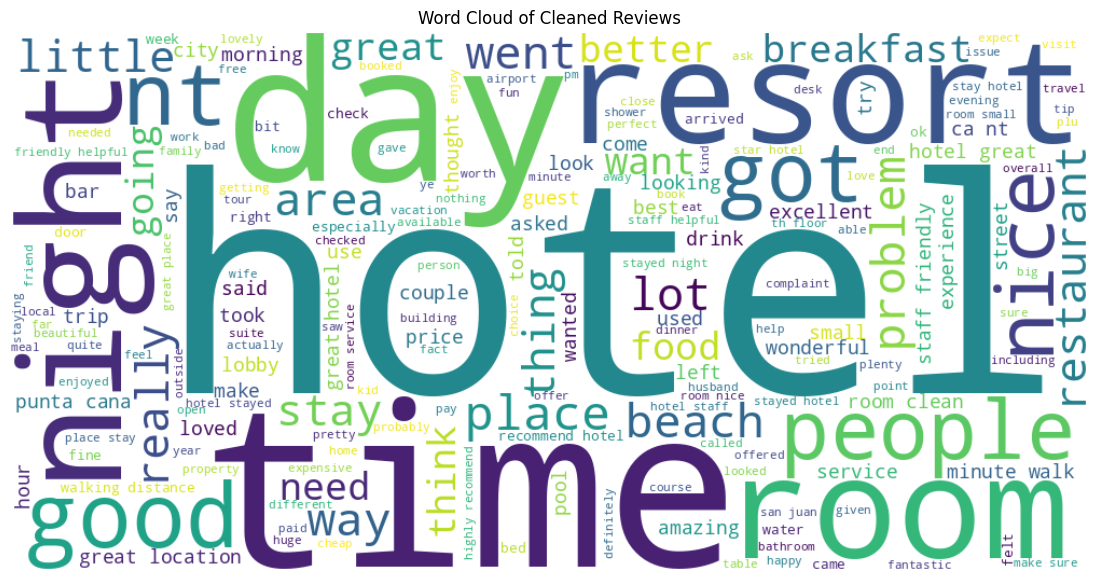

In [64]:
from wordcloud import WordCloud

# Combine all cleaned text
text_data = " ".join(df["clean_review"])

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text_data)

# Plot word cloud
plt.figure(figsize=(15,7))

plt.imshow(wordcloud, interpolation="bilinear")

plt.axis("off")

plt.title("Word Cloud of Cleaned Reviews")

plt.show()

Train-test splits

### Step 9: Train-Test Split and Class Imbalance Handling

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

X = df["clean_review"]
y = df["rating"]

# Convert ratings 1-5 into labels 0-4 for sparse_categorical_crossentropy
y_encoded = y - 1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)



In [66]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())

Training samples: 16392
Testing samples: 4099

Training class distribution:
rating
0    1137
1    1434
2    1747
3    4831
4    7243
Name: count, dtype: int64

Testing class distribution:
rating
0     284
1     359
2     437
3    1208
4    1811
Name: count, dtype: int64


In [68]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("\nClass weights:")
print(class_weight_dict)


Class weights:
{0: np.float64(2.883377308707124), 1: np.float64(2.2861924686192467), 2: np.float64(1.876588437321122), 3: np.float64(0.6786172635065204), 4: np.float64(0.45263012563854754)}


In [8]:
import contractions

Tokenization

### Step 10: Tokenization using Keras Tokenizer

In [69]:

MAX_WORDS = 10000   # maximum vocabulary size
OOV_TOKEN = "<OOV>" # token for unseen words

tokenizer = Tokenizer(
    num_words=MAX_WORDS,
    oov_token=OOV_TOKEN
)

# Fit tokenizer only on training text
tokenizer.fit_on_texts(X_train)

# Convert text into sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index
vocab_size = min(MAX_WORDS, len(word_index) + 1)

print("Total unique words:", len(word_index))
print("Vocabulary size used:", vocab_size)

print("\nExample original text:")
print(X_train.iloc[0])

print("\nExample tokenized sequence:")
print(X_train_seq[0][:30])

Total unique words: 61306
Vocabulary size used: 10000

Example original text:
excellent hotel great location stayed casa camper march night visit barcelona chose hotel mainly based review tripadvisor agree certainly lived glowing report receivedit modern hotel comfortable bedroom nice modern large shower area nice room idea great lovely room bedroom relax long day walking city nice able throw open balcony door relax coffee listening sound coming street getting ready dinner loved fact day snack included room rateit great location la ramblas certainly recommend casa camper planning stay barcelona

Example tokenized sequence:
[35, 2, 4, 13, 15, 2310, 4029, 735, 9, 149, 287, 419, 2, 1291, 592, 46, 703, 817, 329, 1393, 3815, 1254, 1, 167, 2, 53, 361, 12, 167, 69]


Percentile-Based Padding

### Step 11: Percentile-Based Padding

In [70]:

# Calculate sequence lengths from training data only
train_sequence_lengths = [len(seq) for seq in X_train_seq]

# Use 95th percentile length
MAX_LEN = int(np.percentile(train_sequence_lengths, 95))

print("Maximum sequence length using 95th percentile:", MAX_LEN)

# Apply padding
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print("Training padded shape:", X_train_pad.shape)
print("Testing padded shape:", X_test_pad.shape)

Maximum sequence length using 95th percentile: 255
Training padded shape: (16392, 255)
Testing padded shape: (4099, 255)


In [20]:
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")
print(class_weight_dict)

Class weights:
{0: np.float64(2.883377308707124), 1: np.float64(2.2861924686192467), 2: np.float64(1.876588437321122), 3: np.float64(0.6786172635065204), 4: np.float64(0.45263012563854754)}


#Model 1: Simple RNN

In [72]:
# ===============================
# Step 12: Build Simple RNN Model
# ===============================

EMBEDDING_DIM = 100
NUM_CLASSES = 5

rnn_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    SimpleRNN(64),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

rnn_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Compile and Train Simple RNN Model

In [73]:
rnn_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


### Step 13: Train Model 1 using EarlyStopping and Class Weights

In [74]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

rnn_history = rnn_model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

rnn_training_time = time.time() - start_time

print("Simple RNN training completed.")
print("Training time:", round(rnn_training_time, 2), "seconds")

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 123ms/step - accuracy: 0.1853 - loss: 1.6230 - val_accuracy: 0.2608 - val_loss: 1.5999
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 38s 109ms/step - accuracy: 0.2263 - loss: 1.6051 - val_accuracy: 0.1333 - val_loss: 1.6248
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 108ms/step - accuracy: 0.1921 - loss: 1.7288 - val_accuracy: 0.1446 - val_loss: 1.6016
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 23s 113ms/step - accuracy: 0.1941 - loss: 1.6558 - val_accuracy: 0.2845 - val_loss: 1.5814
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 105ms/step - accuracy: 0.2064 - loss: 1.6303 - val_accuracy: 0.2894 - val_loss: 1.5737
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 108ms/step - accuracy: 0.2054 - loss: 1.6235 - val_accuracy: 0.2031 - val_loss: 1.5821
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 102ms/step - accuracy: 0.1990 - loss: 1.6178 - val_accuracy: 0.2870 - val_loss: 1.5754
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 106ms/step - accuracy: 0.2044 - loss: 1

Accuracu and Loss Graphs

### Step 14: Plot Training vs Validation Accuracy and Loss for Simple RNN

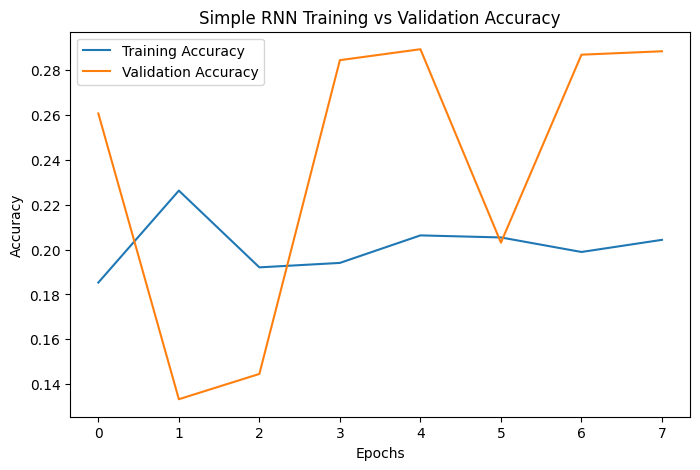

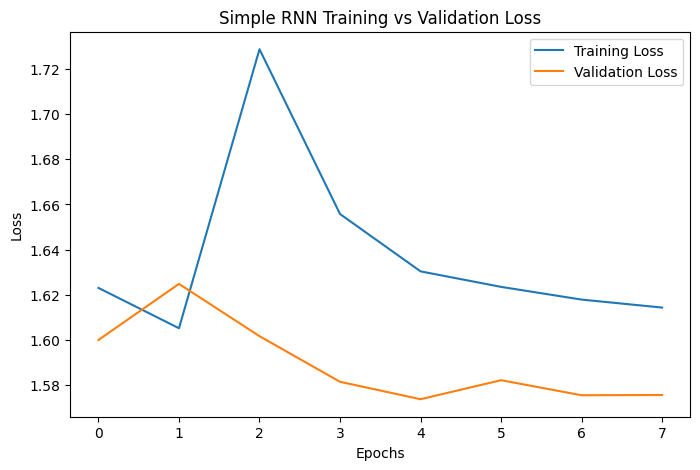

In [75]:
plt.figure(figsize=(8,5))
plt.plot(rnn_history.history["accuracy"], label="Training Accuracy")
plt.plot(rnn_history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Simple RNN Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(rnn_history.history["loss"], label="Training Loss")
plt.plot(rnn_history.history["val_loss"], label="Validation Loss")
plt.title("Simple RNN Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

Model Evaluation

### Step 15: Evaluate Simple RNN Model

This section evaluates the baseline Simple RNN model using accuracy, classification report, and confusion matrix.

In [76]:
# Predict probabilities
rnn_pred_probs = rnn_model.predict(X_test_pad)

# Convert probabilities to class labels
rnn_preds = np.argmax(rnn_pred_probs, axis=1)

# Accuracy
rnn_accuracy = accuracy_score(y_test, rnn_preds)

print("Simple RNN Test Accuracy:", round(rnn_accuracy, 4))

129/129 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
Simple RNN Test Accuracy: 0.2942


In [77]:
print("\nSimple RNN Classification Report:")
print(classification_report(
    y_test,
    rnn_preds,
    target_names=["Rating 1", "Rating 2", "Rating 3", "Rating 4", "Rating 5"]
))



Simple RNN Classification Report:
              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       284
    Rating 2       0.00      0.00      0.00       359
    Rating 3       0.12      0.56      0.19       437
    Rating 4       0.00      0.00      0.00      1208
    Rating 5       0.48      0.53      0.51      1811

    accuracy                           0.29      4099
   macro avg       0.12      0.22      0.14      4099
weighted avg       0.23      0.29      0.24      4099



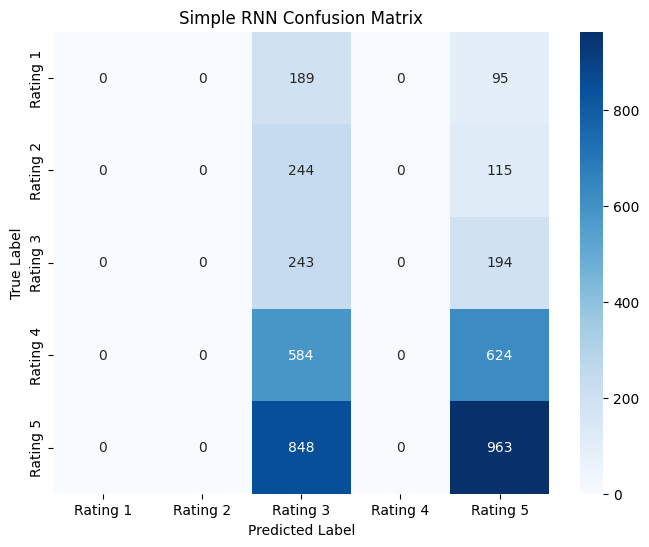

In [78]:
rnn_cm = confusion_matrix(y_test, rnn_preds)

plt.figure(figsize=(8,6))
sns.heatmap(
    rnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Rating 1", "Rating 2", "Rating 3", "Rating 4", "Rating 5"],
    yticklabels=["Rating 1", "Rating 2", "Rating 3", "Rating 4", "Rating 5"]
)

plt.title("Simple RNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

#Model 2: LSTM with Trainable Embedding Layer

### Step 16: Build Model 2 – LSTM with Trainable Embedding

In [80]:
lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

lstm_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [81]:
lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


### Step 17: Train LSTM Model

In [82]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

lstm_history = lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

lstm_training_time = time.time() - start_time

print("LSTM training completed.")
print("Training time:", round(lstm_training_time, 2), "seconds")

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 87s 401ms/step - accuracy: 0.1674 - loss: 1.6123 - val_accuracy: 0.0668 - val_loss: 1.6102
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 96s 465ms/step - accuracy: 0.1637 - loss: 1.6109 - val_accuracy: 0.0686 - val_loss: 1.6141
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 67s 328ms/step - accuracy: 0.2016 - loss: 1.6073 - val_accuracy: 0.2848 - val_loss: 1.6109
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 61s 296ms/step - accuracy: 0.1976 - loss: 1.5884 - val_accuracy: 0.2903 - val_loss: 1.5933
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 82s 298ms/step - accuracy: 0.2588 - loss: 1.5721 - val_accuracy: 0.4434 - val_loss: 1.6192
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 81s 291ms/step - accuracy: 0.2619 - loss: 1.5544 - val_accuracy: 0.4437 - val_loss: 1.6287
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 61s 298ms/step - accuracy: 0.2825 - loss: 1.5370 - val_accuracy: 0.0704 - val_loss: 1.6591
LSTM training completed.
Training time: 535.17 seconds


### Step 18: Plot Training vs Validation Accuracy and Loss for LSTM

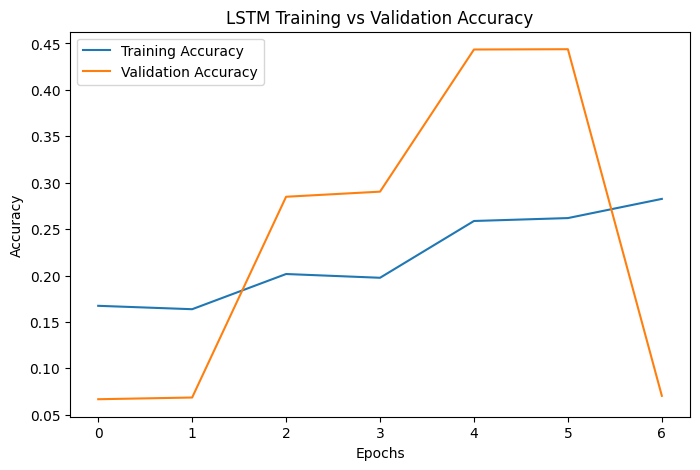

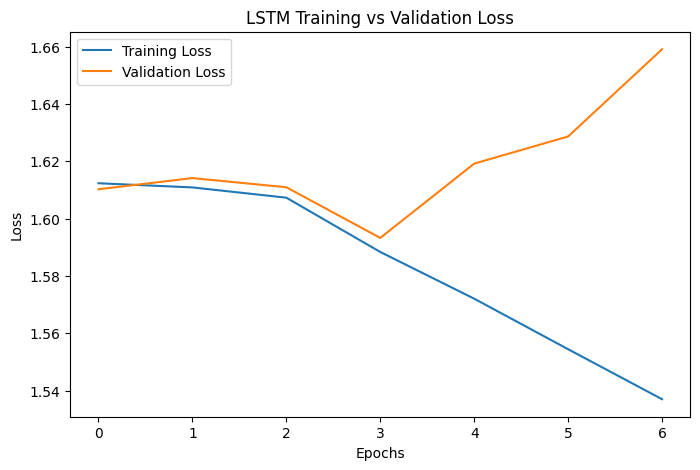

In [83]:
plt.figure(figsize=(8,5))
plt.plot(lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(lstm_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("LSTM Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(lstm_history.history["loss"], label="Training Loss")
plt.plot(lstm_history.history["val_loss"], label="Validation Loss")

plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

### Step 19: Evaluate LSTM Model

This section evaluates the LSTM model using accuracy, classification report, and confusion matrix.

In [84]:
# Predict probabilities
lstm_pred_probs = lstm_model.predict(X_test_pad)

# Convert probabilities into predicted labels
lstm_preds = np.argmax(lstm_pred_probs, axis=1)

print("Predictions generated successfully.")

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step
Predictions generated successfully.


In [85]:
lstm_accuracy = accuracy_score(y_test, lstm_preds)

print("LSTM Test Accuracy:", round(lstm_accuracy, 4))

LSTM Test Accuracy: 0.2908


In [86]:
print("LSTM Classification Report:\n")

print(classification_report(
    y_test,
    lstm_preds,
    target_names=[
        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5"
    ]
))

LSTM Classification Report:

              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       284
    Rating 2       0.15      0.04      0.06       359
    Rating 3       0.17      0.01      0.02       437
    Rating 4       0.29      0.97      0.45      1208
    Rating 5       0.00      0.00      0.00      1811

    accuracy                           0.29      4099
   macro avg       0.12      0.20      0.11      4099
weighted avg       0.12      0.29      0.14      4099



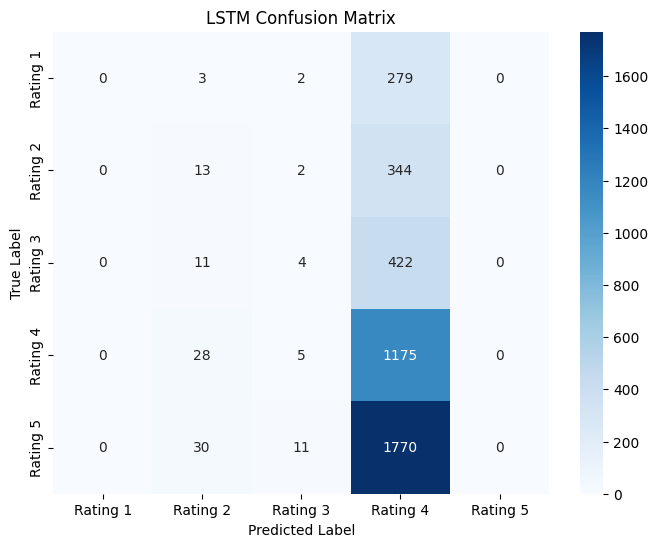

In [87]:
lstm_cm = confusion_matrix(y_test, lstm_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    lstm_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5"
    ],
    yticklabels=[
        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5"
    ]
)

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

### Step 20: Load Pretrained GloVe Embeddings

In [88]:
!pip install gensim

import gensim.downloader as api

embedding_model = api.load("glove-wiki-gigaword-50")

print("Pretrained GloVe embeddings loaded successfully.")
print("Embedding vector size:", embedding_model.vector_size)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 31.4 MB/s eta 0:00:00
[==================================================] 100.0% 66.0/66.0MB downloaded
Pretrained GloVe embeddings loaded successfully.
Embedding vector size: 50


### Step 21: Create Embedding Matrix

In [89]:
GLOVE_EMBEDDING_DIM = 50

embedding_matrix = np.zeros((vocab_size, GLOVE_EMBEDDING_DIM))

matched_words = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue

    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        matched_words += 1

print("Embedding matrix shape:", embedding_matrix.shape)
print("Matched words:", matched_words)
print("Vocabulary size:", vocab_size)
print("Coverage percentage:", round((matched_words / vocab_size) * 100, 2), "%")

Embedding matrix shape: (10000, 50)
Matched words: 9162
Vocabulary size: 10000
Coverage percentage: 91.62 %


### Step 22: Build Model 3 – GloVe + LSTM

In [90]:
glove_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=GLOVE_EMBEDDING_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(NUM_CLASSES, activation="softmax")
])

glove_lstm_model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

glove_lstm_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

### Step 23: Train GloVe + LSTM Model

In [91]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

start_time = time.time()

glove_lstm_history = glove_lstm_model.fit(
    X_train_pad,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    class_weight=class_weight_dict,
    verbose=1
)

glove_lstm_training_time = time.time() - start_time

print("GloVe + LSTM training completed.")
print("Training time:", round(glove_lstm_training_time, 2), "seconds")

Epoch 1/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 39s 155ms/step - accuracy: 0.2088 - loss: 1.6111 - val_accuracy: 0.1003 - val_loss: 1.6161
Epoch 2/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 152ms/step - accuracy: 0.2449 - loss: 1.6101 - val_accuracy: 0.2797 - val_loss: 1.6157
Epoch 3/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 155ms/step - accuracy: 0.2113 - loss: 1.6084 - val_accuracy: 0.4385 - val_loss: 1.6064
Epoch 4/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 42s 206ms/step - accuracy: 0.2812 - loss: 1.6084 - val_accuracy: 0.4392 - val_loss: 1.6028
Epoch 5/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 63s 306ms/step - accuracy: 0.2723 - loss: 1.6056 - val_accuracy: 0.4416 - val_loss: 1.5777
Epoch 6/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 51s 155ms/step - accuracy: 0.2490 - loss: 1.6060 - val_accuracy: 0.1052 - val_loss: 1.6055
Epoch 7/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 149ms/step - accuracy: 0.1888 - loss: 1.6033 - val_accuracy: 0.0723 - val_loss: 1.6127
Epoch 8/20
205/205 ━━━━━━━━━━━━━━━━━━━━ 58s 233ms/step - accuracy: 0.2216 - loss: 1

### Step 24: Plot Training vs Validation Accuracy and Loss for GloVe + LSTM

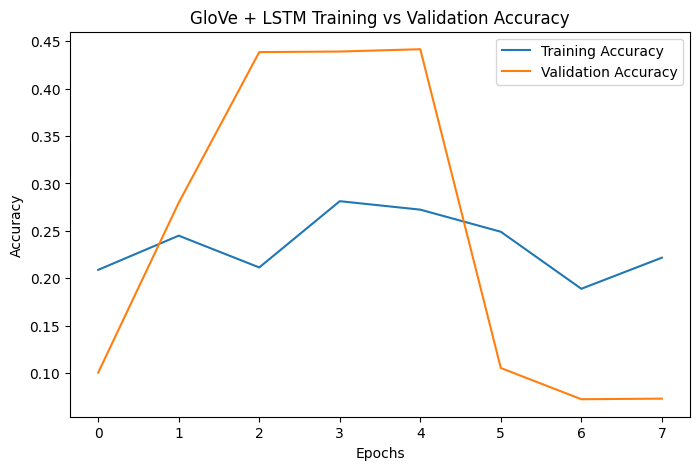

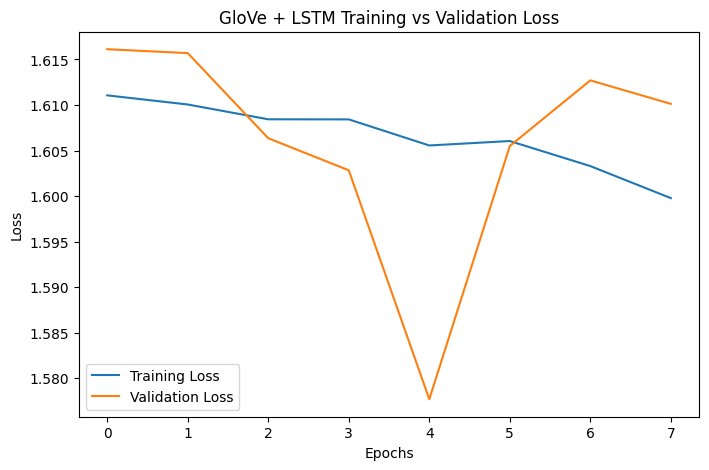

In [92]:
plt.figure(figsize=(8,5))
plt.plot(glove_lstm_history.history["accuracy"], label="Training Accuracy")
plt.plot(glove_lstm_history.history["val_accuracy"], label="Validation Accuracy")

plt.title("GloVe + LSTM Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.legend()
plt.show()


plt.figure(figsize=(8,5))
plt.plot(glove_lstm_history.history["loss"], label="Training Loss")
plt.plot(glove_lstm_history.history["val_loss"], label="Validation Loss")

plt.title("GloVe + LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")

plt.legend()
plt.show()

### Step 25: Evaluate GloVe + LSTM Model

This section evaluates the pretrained embedding model using accuracy, classification report, and confusion matrix.

In [93]:
glove_pred_probs = glove_lstm_model.predict(X_test_pad)

glove_preds = np.argmax(glove_pred_probs, axis=1)

print("Predictions generated successfully.")

129/129 ━━━━━━━━━━━━━━━━━━━━ 11s 80ms/step
Predictions generated successfully.


In [94]:

glove_accuracy = accuracy_score(y_test, glove_preds)

print("GloVe + LSTM Test Accuracy:", round(glove_accuracy, 4))

GloVe + LSTM Test Accuracy: 0.4333


In [95]:
print("GloVe + LSTM Classification Report:\n")

print(classification_report(
    y_test,
    glove_preds,
    target_names=[
        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5"
    ]
))

GloVe + LSTM Classification Report:

              precision    recall  f1-score   support

    Rating 1       0.00      0.00      0.00       284
    Rating 2       0.11      0.03      0.05       359
    Rating 3       0.15      0.01      0.03       437
    Rating 4       0.29      0.01      0.02      1208
    Rating 5       0.45      0.97      0.61      1811

    accuracy                           0.43      4099
   macro avg       0.20      0.20      0.14      4099
weighted avg       0.31      0.43      0.28      4099



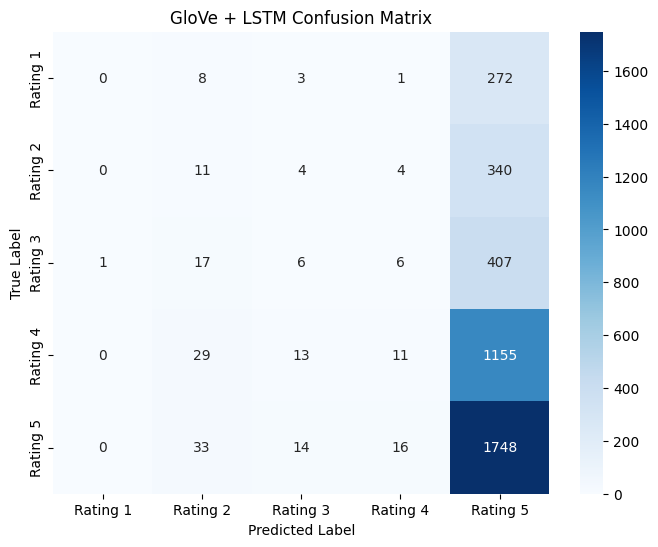

In [96]:
glove_cm = confusion_matrix(y_test, glove_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    glove_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5"
    ],
    yticklabels=[
        "Rating 1",
        "Rating 2",
        "Rating 3",
        "Rating 4",
        "Rating 5"
    ]
)

plt.title("GloVe + LSTM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## 4.5.3 Model Comparison and Evaluation

### Step 26: Compare RNN vs LSTM vs GloVe + LSTM

In [97]:

comparison_df = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "GloVe + LSTM"
    ],

    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        glove_accuracy
    ],

    "Training Time (seconds)": [
        round(rnn_training_time, 2),
        round(lstm_training_time, 2),
        round(glove_lstm_training_time, 2)
    ]
})

comparison_df

,Model,Accuracy,Training Time (seconds)
0,Simple RNN,0.294218,238.87
1,LSTM,0.290803,535.17
2,GloVe + LSTM,0.433276,381.34


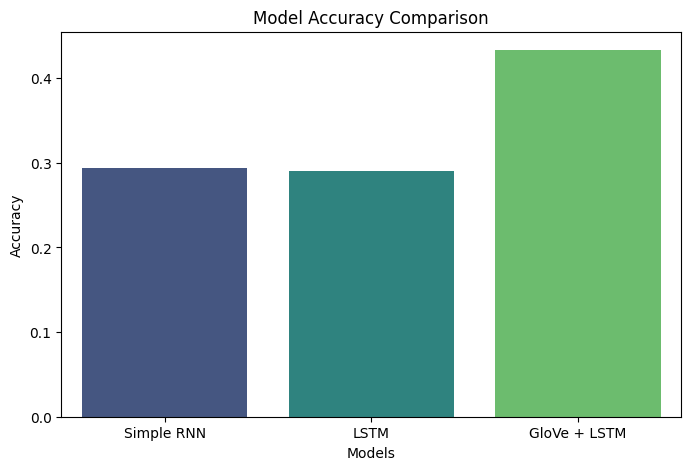

In [98]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=comparison_df,
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

plt.show()

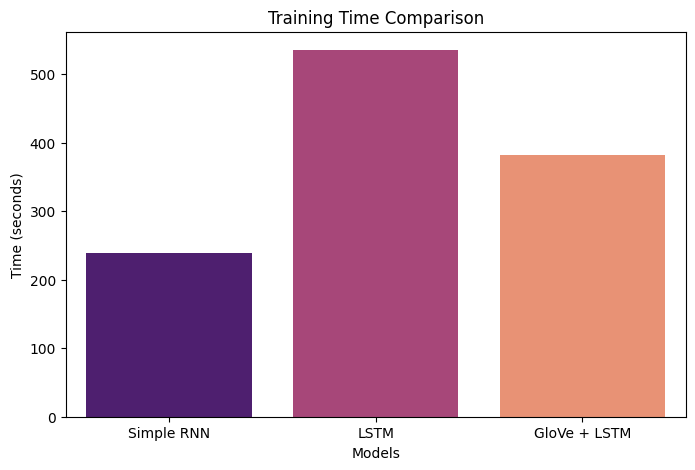

In [99]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Training Time (seconds)",
    data=comparison_df,
    palette="magma"
)

plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")
plt.xlabel("Models")

plt.show()

## 4.5.4 Error Analysis

### Step 27: Misclassified Examples

In [100]:

results_df = pd.DataFrame({
    "Review": X_test.values,
    "True_Label": y_test.values + 1,
    "Predicted_Label": glove_preds + 1
})

results_df.head()

,Review,True_Label,Predicted_Label
0,great location nice staff mattress soft night ...,3,5
1,nice hotel nice hotel good area explore arriva...,3,5
2,star price star service booked lovely hotel we...,5,5
3,felt welcome location location location wife s...,5,5
4,wonderful week say good thing hotel service co...,5,5


In [101]:

misclassified = results_df[
    results_df["True_Label"] != results_df["Predicted_Label"]
]

print("Total Misclassified Examples:", len(misclassified))

misclassified.head(3)

Total Misclassified Examples: 2323


,Review,True_Label,Predicted_Label
0,great location nice staff mattress soft night ...,3,5
1,nice hotel nice hotel good area explore arriva...,3,5
5,stayed hotel group friend interesting mixed vi...,4,5


In [102]:

for i in range(3):

    print("="*100)

    print(f"Review {i+1}:\n")

    print(misclassified.iloc[i]["Review"])

    print("\nActual Rating:",
          misclassified.iloc[i]["True_Label"])

    print("Predicted Rating:",
          misclassified.iloc[i]["Predicted_Label"])

    print("="*100)

Review 1:

great location nice staff mattress soft night stay early september hotel agora st germaine fabulous neighborhood great location near metro stop shop boulangerie food kiosk ethnic food restaurant internet cafe nearby best hotel location desk staff speaks english competently help hotel neighborhood info provide concierge service like getting ticket event room adequate small parisian standard clean serviced maid tiny room safe capable holding couple passport elevator small slow work room air conditioning bit anemic hottest day quite adequate bed double mattress sized double room lacking firmness support north american used bad value price euro

Actual Rating: 3
Predicted Rating: 5
Review 2:

nice hotel nice hotel good area explore arrival greated glass bubbly juice arrived early room ready great room road noisy night room quite hot sleep window open extremely noisy bathroom okay water shower going problem used towel reception bought towel quite quickly room clean bed comfortabl

### Step 33: Create Prediction Function

In [103]:
rating_labels = {
    0: "Rating 1",
    1: "Rating 2",
    2: "Rating 3",
    3: "Rating 4",
    4: "Rating 5"
}

def predict_review(review):

    # Clean text
    cleaned_review = clean_text(review)

    # Convert to sequence
    sequence = tokenizer.texts_to_sequences([cleaned_review])

    # Apply padding
    padded_sequence = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    # Predict
    prediction = glove_lstm_model.predict(padded_sequence)

    predicted_class = np.argmax(prediction, axis=1)[0]

    return rating_labels[predicted_class]

### Step 34: Build Gradio GUI

In [104]:
import gradio as gr

interface = gr.Interface(
    fn=predict_review,

    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a hotel review here..."
    ),

    outputs="text",

    title="Hotel Review Rating Prediction",

    description="Enter a hotel review and predict its rating using the trained GloVe + LSTM model."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7550c61f75e5239cad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Additional Required Sections to Review

The following PDF-required sections were not automatically matched to an existing code cell. Add the related code/analysis below if it is missing:

### Step 5: Download NLP Resources

## 4.5.2 Model Building and Training

### Step 12: Build Model 1 – Simple RNN with Trainable Embedding

### Step 28: Overfitting and Underfitting Analysis

### Step 29: Model Complexity vs Performance

### Step 30: Possible Reasons for Errors

### Step 31: Suggested Improvements

## 4.5.5 GUI for Real-Time Prediction

### Step 32: Install Gradio

### Step 35: Sample Reviews for Testing

## Final Conclusion

## Final Requirement Checklist

## Viva-Ready Explanation